# Chile Mineral Supply Chain: Data Pipeline and Network Analysis

This notebook runs the complete workflow for analysing Chile's mine-to-processing-plant supply chain. It is split into two parts:

**Part A (Sections 0-8): Data pipeline.** Downloads facility data from Sernageomin's ArcGIS service, loads USGS mineral processing facilities and HS92 trade data, harmonises commodity names, deduplicates across sources, infers mine-to-plant links by commodity and proximity, and cross-references with export statistics.

**Part B (Sections 9-22): Network analysis and visualisation.** Constructs a bipartite network from the inferred links, computes centrality metrics, detects communities (Louvain), builds unipartite projections, analyses commodity subnetworks, and produces static plots, an interactive D3 force-directed graph, and an interactive Folium geographic map.

**Inputs:**
- ArcGIS FeatureServer (Sernageomin, downloaded live)
- `MINFAC_LAC.csv` (USGS, local)
- `Chile_HS92_Exports_6digit.csv` (Harvard Growth Lab, local)

**Outputs (organised into subdirectories):**

| Folder | Contents |
|---|---|
| `Outputs/` | Static PNGs (network plot, centrality, communities, commodity comparison, projections, supply chain map) |
| `Interactive/` | HTML files (D3 force-directed network, Folium geographic map) |
| `Preliminary/` | `Chile_Minerals_Inventory.csv`, `Chile_Minerals_Inventory.geojson`, `Chile_Mine_Plant_Links.csv`, `Chile_Supply_Chain_Summary.csv`, `Chile_Network_Metrics.csv`, `Chile_Network_Summary.txt` |

## 0. Setup

In [74]:
import os, json, time, warnings, requests
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec

import folium

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 9,
    "axes.titlesize": 11, "axes.labelsize": 9,
    "figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#cccccc", "grid.color": "#e0e0e0", "grid.linewidth": 0.5,
})

# Paths
BASE_DIR = "/Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile"
USGS_PATH = "/Users/leoss/Downloads/MINFAC_LAC.csv"
HS92_PATH = os.path.join("/Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/data", "hs92_country_product_year_6.csv")
LINKS_PATH = os.path.join(BASE_DIR, "Chile_Mine_Plant_Links.csv")
INVENTORY_PATH = os.path.join(BASE_DIR, "Chile_Minerals_Inventory.csv")

DIR_OUT    = os.path.join(BASE_DIR, "Outputs")
DIR_HTML   = os.path.join(BASE_DIR, "Interactive")
DIR_PRELIM = os.path.join(BASE_DIR, "Preliminary")
for d in [DIR_OUT, DIR_HTML, DIR_PRELIM]:
    os.makedirs(d, exist_ok=True)

# ArcGIS endpoint
BASE_URL = "https://services1.arcgis.com/OyjvVdFTl5hfSdX3/arcgis/rest/services/EMC_F/FeatureServer"

# Chile bounding box (mainland)
CHILE_LAT_MIN, CHILE_LAT_MAX = -56.0, -17.5
CHILE_LON_MIN, CHILE_LON_MAX = -76.0, -66.0

LINK_MAX_KM = 150  # max mine-plant distance

# Commodity colour palette
COMMODITY_COLORS = {
    "Copper": "#d63031", "Gold": "#fdcb6e", "Silver": "#636e72",
    "Iron": "#e17055", "Molybdenum": "#6c5ce7", "Iodine": "#00b894",
    "Nitrate": "#00cec9", "Rhenium": "#a29bfe", "Manganese": "#e84393",
    "Zinc": "#74b9ff", "Boron": "#55efc4", "Lithium": "#fd79a8",
}
DEFAULT_COLOR = "#b2bec3"

def commodity_color(c):
    return COMMODITY_COLORS.get(c, DEFAULT_COLOR)

start_time = time.time()

## 1. Commodity harmonisation and helper functions

Spanish-to-English mappings for Sernageomin data, plus USGS naming inconsistencies. Helper functions for ArcGIS download, haversine distance, facility classification, and commodity parsing.

In [75]:
# Spanish -> English and USGS inconsistencies
COMMODITY_MAP = {
    "Cobre": "Copper", "Oro": "Gold", "Plata": "Silver",
    "Hierro": "Iron", "Litio": "Lithium", "Nitrato": "Nitrate",
    "Boro": "Boron", "Cinc": "Zinc", "Manganeso": "Manganese",
    "Titanio": "Titanium", "Tierras raras": "Rare Earths",
    "Molibdeno": "Molybdenum", "Cobalto": "Cobalt", "Renio": "Rhenium",
    "Potasio": "Potassium", "Yodo": "Iodine", "Selenio": "Selenium",
    "Telurio": "Tellurium", "Antimonio": "Antimony",
    "Nitrates": "Nitrate", "Iron and steel": "Iron",
    "Sulfuric acid": "Sulfuric Acid", "Calcium carbonate": "Calcium Carbonate",
    "Phosphatic materials": "Phosphate", "Sodium sulfate": "Sodium Sulfate",
    "Potassium chloride": "Potassium", "Natural gas": "Natural Gas",
}

def harmonize_commodity(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return COMMODITY_MAP.get(name, name)

def parse_commodity_list(combo_string):
    if pd.isna(combo_string):
        return []
    parts = str(combo_string).replace(",", "-").replace("/", "-").split("-")
    return [harmonize_commodity(p.strip()) for p in parts if p.strip()]

def classify_usgs_plant(name):
    name = str(name).lower()
    for kw, label in [("smelter", "Smelter"), ("refin", "Refinery"),
                       ("sx-ew", "SX-EW Plant"), ("sx/ew", "SX-EW Plant"),
                       ("concentrat", "Concentrator"), ("flotation", "Concentrator"),
                       ("milling", "Concentrator"), ("pellet", "Pellet Plant"),
                       ("grinding", "Grinding Plant"), ("steel", "Steel Plant")]:
        if kw in name:
            return label
    return "Processing Plant"

USGS_STATUS_MAP = {"A": "Active", "C": "Closed", "S": "Standby", "CM": "Care & Maintenance"}

FACILITY_STAGE = {
    "Mine (active)": "extraction", "Mine (idle)": "extraction",
    "Prospect/Project": "extraction", "Mine (USGS)": "extraction",
    "Concentrator": "processing", "SX-EW Plant": "processing",
    "Smelter": "processing", "Refinery": "processing",
    "Processing Plant": "processing", "Pellet Plant": "processing",
    "Grinding Plant": "processing", "Steel Plant": "processing",
}

def download_layer(layer_id, with_geometry=True):
    all_features, offset = [], 0
    while True:
        params = {"where": "1=1", "outFields": "*", "f": "json",
                  "resultRecordCount": 2000, "resultOffset": offset}
        if with_geometry:
            params.update({"outSR": "4326", "returnGeometry": "true"})
        r = requests.get(f"{BASE_URL}/{layer_id}/query", params=params, timeout=60)
        r.raise_for_status()
        features = r.json().get("features", [])
        if not features:
            break
        all_features.extend(features)
        if len(features) < 2000:
            break
        offset += len(features)
    return all_features

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

## 2. Download Sernageomin critical minerals

Downloads deposit and reserve/resource records from Sernageomin's ArcGIS FeatureServer. Reserve data is pivoted so each deposit has one row with resource and reserve columns per commodity.

In [76]:
dep_features = download_layer(0, with_geometry=True)
res_features = download_layer(3, with_geometry=False)
print(f"Deposits: {len(dep_features)}, Reserve/resource records: {len(res_features)}")

rows = []
for feat in dep_features:
    row = feat.get("attributes", {})
    geom = feat.get("geometry")
    if geom and "x" in geom:
        row["geometry"] = Point(geom["x"], geom["y"])
        row["LATITUD"] = geom["y"]
        row["LONGITUD"] = geom["x"]
    else:
        row["geometry"] = None
    rows.append(row)
serna_gdf = gpd.GeoDataFrame(pd.DataFrame(rows), geometry="geometry", crs="EPSG:4326")

# Pivot reserves
reservas = pd.DataFrame([f["attributes"] for f in res_features])
if len(reservas) > 0:
    rp = reservas.pivot_table(index="ID_DEPOSITO", columns=["MINERAL", "TIPO"],
                              values="VALOR", aggfunc="sum")
    rp.columns = [f"{m}_{t}" for m, t in rp.columns]
    rp = rp.reset_index()
    serna_gdf = serna_gdf.merge(rp, left_on="ID", right_on="ID_DEPOSITO", how="left")
    serna_gdf.drop(columns=["ID_DEPOSITO"], errors="ignore", inplace=True)

# Standardise columns
serna_gdf["SOURCE"] = "Sernageomin_2025"
serna_gdf["STATUS"] = serna_gdf["ESTADO_DEPOSITO"].map({
    "Mina en producci\u00f3n": "Active", "Mina paralizada": "Idle",
    "Mina Paralizada": "Idle", "Prospecto/Proyecto": "Prospect/Project"})
serna_gdf["FACILITY_TYPE"] = serna_gdf["ESTADO_DEPOSITO"].map({
    "Mina en producci\u00f3n": "Mine (active)", "Mina paralizada": "Mine (idle)",
    "Mina Paralizada": "Mine (idle)", "Prospecto/Proyecto": "Prospect/Project"})
serna_gdf["FACILITY_NAME"] = serna_gdf["NOMBRE_DEPOSITO"]
serna_gdf["PRIMARY_COMMODITY"] = serna_gdf["CRITICO_1"].apply(harmonize_commodity)
serna_gdf["ALL_COMMODITIES_RAW"] = serna_gdf["COMBINACION_CRITICO"]
for col in ["OPERATOR_NAME", "OWNER_NAME", "CAPACITY", "CAPACITY_UNITS"]:
    serna_gdf[col] = None

# Rename reserve columns to English
rename = {}
for col in serna_gdf.columns:
    new = col
    for es, en in COMMODITY_MAP.items():
        if es in new:
            new = new.replace(es, en)
    new = new.replace("_Recurso", "_Resource").replace("_Reserva", "_Reserve")
    if new != col:
        rename[col] = new
serna_gdf.rename(columns=rename, inplace=True)

print(f"Sernageomin: {serna_gdf.shape}")

Deposits: 267, Reserve/resource records: 365
Sernageomin: (267, 65)


## 3. Load USGS mineral facilities

Loads processing plants and mine records from the USGS MINFAC_LAC dataset. Plants are kept as network nodes; mine records provide ownership data for Sernageomin enrichment.

In [77]:
usgs = pd.read_csv(USGS_PATH, encoding="latin-1")
chile_usgs = usgs[usgs["COUNTRY"].str.strip().str.lower() == "chile"].copy()

plants = chile_usgs[chile_usgs["FACTYPE"].isin(["P", "B", "OR", "MP", "p"])].copy()
plants["FACILITY_TYPE"] = plants["LOCNAME"].apply(classify_usgs_plant)

usgs_mines = chile_usgs[chile_usgs["FACTYPE"].isin(["M", "m", "DM", "SM"])].copy()
usgs_mines["FACILITY_TYPE"] = "Mine (USGS)"

plants["geometry"] = plants.apply(
    lambda r: Point(r["DDLONG"], r["DDLAT"])
    if pd.notna(r["DDLAT"]) and pd.notna(r["DDLONG"]) else None, axis=1)
plants_gdf = gpd.GeoDataFrame(plants, geometry="geometry", crs="EPSG:4326")

plants_gdf["SOURCE"] = "USGS_MINFAC_2017"
plants_gdf["FACILITY_NAME"] = plants_gdf["LOCNAME"]
plants_gdf["PRIMARY_COMMODITY"] = plants_gdf["COMMODITY"].apply(harmonize_commodity)
plants_gdf["ALL_COMMODITIES_RAW"] = plants_gdf["COMMODITY"]
plants_gdf["OPERATOR_NAME"] = plants_gdf["OPERATOR"]
plants_gdf["OWNER_NAME"] = plants_gdf["OWNER"]
plants_gdf["CAPACITY"] = plants_gdf["ANNCAP"]
plants_gdf["CAPACITY_UNITS"] = plants_gdf["UNITS"]
plants_gdf["LATITUD"] = plants_gdf["DDLAT"]
plants_gdf["LONGITUD"] = plants_gdf["DDLONG"]
plants_gdf["REGION"] = plants_gdf["ADM1"]
plants_gdf["STATUS"] = plants_gdf["STATUS"].map(USGS_STATUS_MAP).fillna(plants_gdf["STATUS"])

usgs_mines_df = usgs_mines[["LOCNAME", "COMMODITY", "OPERATOR", "OWNER", "DDLAT", "DDLONG"]].copy()
usgs_mines_df["LOCNAME_lower"] = usgs_mines_df["LOCNAME"].str.lower().str.strip()

print(f"USGS Chile: {len(chile_usgs)} total, {len(plants)} plants, {len(usgs_mines)} mines")

USGS Chile: 394 total, 194 plants, 192 mines


## 4. Merge and deduplicate

Combines Sernageomin and USGS records into a single inventory. Where a Sernageomin mine matches a USGS mine record by name prefix and commodity, ownership data is transferred. Exact duplicates (same name, same commodity, both extraction-stage) are dropped from the USGS side.

In [78]:
all_cols = list(set(serna_gdf.columns) | set(plants_gdf.columns))
for col in all_cols:
    if col not in serna_gdf.columns:
        serna_gdf[col] = None
    if col not in plants_gdf.columns:
        plants_gdf[col] = None

combined = gpd.GeoDataFrame(
    pd.concat([serna_gdf[all_cols], plants_gdf[all_cols]], ignore_index=True), crs="EPSG:4326")
print(f"Before dedup: {len(combined)}")

# Enrich Sernageomin ownership from USGS mine records
serna_mask = combined["SOURCE"] == "Sernageomin_2025"
serna_rows = combined[serna_mask].copy()
serna_rows["name_lower"] = serna_rows["FACILITY_NAME"].str.lower().str.strip()

enriched = 0
for idx, row in serna_rows.iterrows():
    matches = usgs_mines_df[usgs_mines_df["LOCNAME_lower"].str.contains(
        row["name_lower"][:8], case=False, na=False, regex=False)]
    if len(matches) > 0:
        best = matches.iloc[0]
        if pd.isna(combined.at[idx, "OPERATOR_NAME"]) and pd.notna(best["OPERATOR"]):
            combined.at[idx, "OPERATOR_NAME"] = best["OPERATOR"]
            enriched += 1
        if pd.isna(combined.at[idx, "OWNER_NAME"]) and pd.notna(best["OWNER"]):
            combined.at[idx, "OWNER_NAME"] = best["OWNER"]
print(f"Enriched {enriched} records with USGS ownership")

# Drop USGS duplicates of Sernageomin extraction records
combined["_name_lower"] = combined["FACILITY_NAME"].str.lower().str.strip()
combined["_stage"] = combined["FACILITY_TYPE"].map(FACILITY_STAGE)
usgs_mask = combined["SOURCE"] == "USGS_MINFAC_2017"

dupes = []
for _, srow in combined[serna_mask & (combined["_stage"] == "extraction")].iterrows():
    pot = combined[usgs_mask & (combined["_name_lower"] == srow["_name_lower"])
                   & (combined["PRIMARY_COMMODITY"] == srow["PRIMARY_COMMODITY"])]
    dupes.extend(pot.index.tolist())
dupes = list(set(dupes))
if dupes:
    combined.drop(index=dupes, inplace=True)
    print(f"Dropped {len(dupes)} USGS duplicates")

combined.drop(columns=["_name_lower", "_stage"], errors="ignore", inplace=True)
combined.reset_index(drop=True, inplace=True)
print(f"After dedup: {len(combined)}")

Before dedup: 461
Enriched 62 records with USGS ownership
After dedup: 461


## 5. Parse secondary commodities

Parses multi-commodity strings (e.g. "Copper-Molybdenum-Rhenium") into lists, creating an exploded view for commodity-level lookups used in mine-plant linking.

In [79]:
combined["COMMODITY_LIST"] = combined["ALL_COMMODITIES_RAW"].apply(parse_commodity_list)
combined["N_COMMODITIES"] = combined["COMMODITY_LIST"].apply(len)

multi = combined[combined["N_COMMODITIES"] > 1]
print(f"Multi-commodity facilities: {len(multi)}, max per facility: {combined['N_COMMODITIES'].max()}")

exploded = combined.explode("COMMODITY_LIST").reset_index(drop=True)
exploded = exploded.drop(columns=["COMMODITY"], errors="ignore")
exploded = exploded.rename(columns={"COMMODITY_LIST": "COMMODITY"})
exploded = exploded[exploded["COMMODITY"].notna() & (exploded["COMMODITY"].astype(str) != "")].reset_index(drop=True)

commodity_counts = exploded.groupby("COMMODITY")["FACILITY_NAME"].count().sort_values(ascending=False)
print(f"Unique commodities: {len(commodity_counts)}")
print(commodity_counts.head(15).to_string())

Multi-commodity facilities: 142, max per facility: 4
Unique commodities: 44
COMMODITY
Copper               193
Gold                 103
Silver                63
Molybdenum            44
Iron                  26
Nitrate               21
Iodine                21
Boron                 20
Calcium Carbonate     16
Cobalt                16
Lithium               15
Zinc                  14
Rhenium               14
Silica                10
Potassium              9


## 6. Geographic consistency checks

Flags any records falling outside Chile's mainland bounding box or near the Argentine border.

In [80]:
has_coords = combined[combined["LATITUD"].notna() & combined["LONGITUD"].notna()].copy()
print(f"Records with coordinates: {len(has_coords)} / {len(combined)}")

outside = has_coords[
    (has_coords["LONGITUD"] > CHILE_LON_MAX) | (has_coords["LONGITUD"] < CHILE_LON_MIN) |
    (has_coords["LATITUD"] > CHILE_LAT_MAX) | (has_coords["LATITUD"] < CHILE_LAT_MIN)]
if len(outside) > 0:
    print(f"{len(outside)} records OUTSIDE Chile bounding box:")
    print(outside[["FACILITY_NAME", "REGION", "LONGITUD", "LATITUD", "PRIMARY_COMMODITY", "SOURCE"]].to_string(index=False))
else:
    print("All records within Chile bounding box.")

border = has_coords[has_coords["LONGITUD"] > -67.5].sort_values("LONGITUD", ascending=False)
print(f"Border-zone records (lon > -67.5): {len(border)}")
if len(border) > 0:
    print(border[["FACILITY_NAME", "REGION", "LONGITUD", "LATITUD", "PRIMARY_COMMODITY"]].to_string(index=False))

Records with coordinates: 461 / 461
All records within Chile bounding box.
Border-zone records (lon > -67.5): 5
              FACILITY_NAME                               REGION   LONGITUD    LATITUD PRIMARY_COMMODITY
       Lavadero Isla Picton Magallanes y de la Antártica Chilena -66.950000 -55.033333              Gold
         Salar de Quisquiro                          Antofagasta -67.270000 -23.220000             Boron
Salar Aguas Calientes Norte                          Antofagasta -67.410000 -23.120000             Boron
                    El Laco                          Antofagasta -67.476667 -23.826667              Iron
El Laco concentration plant                          Antofagasta -67.485600 -23.843500              Iron


## 7. Link mines to processing facilities

For each mine, identifies all processing plants that handle at least one shared commodity within the distance threshold (150 km by default). Links are ranked by distance.

In [81]:
combined["_stage"] = combined["FACILITY_TYPE"].map(FACILITY_STAGE)

mines = combined[(combined["_stage"] == "extraction")
                 & combined["LATITUD"].notna() & combined["LONGITUD"].notna()].copy()
plants_link = combined[(combined["_stage"] == "processing")
                       & combined["LATITUD"].notna() & combined["LONGITUD"].notna()].copy()

print(f"Mines/prospects with coords: {len(mines)}")
print(f"Processing facilities with coords: {len(plants_link)}")

mine_comms = {idx: set(r.get("COMMODITY_LIST") or [r["PRIMARY_COMMODITY"]]) for idx, r in mines.iterrows()}
plant_comms = {idx: set(r.get("COMMODITY_LIST") or [r["PRIMARY_COMMODITY"]]) for idx, r in plants_link.iterrows()}

link_rows = []
for midx, mrow in mines.iterrows():
    mc = mine_comms[midx]
    if not mc:
        continue
    for pidx, prow in plants_link.iterrows():
        shared = mc & plant_comms[pidx]
        if not shared:
            continue
        dist = haversine_km(mrow["LATITUD"], mrow["LONGITUD"], prow["LATITUD"], prow["LONGITUD"])
        if dist <= LINK_MAX_KM:
            link_rows.append({
                "MINE_NAME": mrow["FACILITY_NAME"], "MINE_IDX": midx,
                "MINE_TYPE": mrow["FACILITY_TYPE"], "MINE_STATUS": mrow["STATUS"],
                "MINE_LAT": mrow["LATITUD"], "MINE_LON": mrow["LONGITUD"],
                "MINE_REGION": mrow.get("REGION"), "MINE_OPERATOR": mrow.get("OPERATOR_NAME"),
                "PLANT_NAME": prow["FACILITY_NAME"], "PLANT_IDX": pidx,
                "PLANT_TYPE": prow["FACILITY_TYPE"], "PLANT_STATUS": prow["STATUS"],
                "PLANT_LAT": prow["LATITUD"], "PLANT_LON": prow["LONGITUD"],
                "PLANT_OPERATOR": prow.get("OPERATOR_NAME"), "PLANT_OWNER": prow.get("OWNER_NAME"),
                "PLANT_CAPACITY": prow.get("CAPACITY"), "PLANT_CAPACITY_UNITS": prow.get("CAPACITY_UNITS"),
                "SHARED_COMMODITIES": ", ".join(sorted(shared)),
                "DISTANCE_KM": round(dist, 1),
            })

links_df = pd.DataFrame(link_rows)
if len(links_df) > 0:
    links_df.sort_values(["MINE_NAME", "DISTANCE_KM"], inplace=True)
    print(f"Links: {len(links_df)}, unique mines: {links_df['MINE_NAME'].nunique()}, "
          f"unique plants: {links_df['PLANT_NAME'].nunique()}")
    unlinked = mines[~mines.index.isin(set(links_df['MINE_IDX']))]
    print(f"Mines with no nearby processing: {len(unlinked)}")
    if len(unlinked) > 0:
        print(unlinked["PRIMARY_COMMODITY"].value_counts().to_string())
else:
    print("No links found within distance threshold.")

combined.drop(columns=["_stage"], errors="ignore", inplace=True)

Mines/prospects with coords: 267
Processing facilities with coords: 194
Links: 1370, unique mines: 206, unique plants: 78
Mines with no nearby processing: 60
PRIMARY_COMMODITY
Gold           20
Copper         11
Lithium         8
Boron           6
Titanium        4
Manganese       4
Rare Earths     3
Silver          2
Zinc            2


## 8. Trade data cross-reference and save pipeline outputs

Matches mineral commodities to HS92 6-digit product codes and computes export values. Determines whether each commodity has domestic extraction, processing, or both. Saves the full inventory, links, and summary to `Preliminary/`.

In [82]:
# HS92 commodity -> product code mapping
HS92_COMMODITY_MAP = {
    "Copper": {"260300": "Copper ores and concentrates", "740311": "Refined copper, cathodes",
               "740312": "Refined copper, wire bars", "740400": "Copper waste and scrap",
               "740319": "Refined copper, other", "740321": "Copper alloys, copper-zinc",
               "740329": "Copper alloys, other"},
    "Lithium": {"283691": "Lithium carbonate", "253090": "Lithium minerals (ores)"},
    "Molybdenum": {"261310": "Molybdenum ores, roasted", "261390": "Molybdenum ores, other",
                   "810294": "Molybdenum, unwrought"},
    "Gold": {"710812": "Gold, non-monetary, unwrought", "261690": "Precious metal ores"},
    "Silver": {"710691": "Silver, unwrought", "261610": "Silver ores and concentrates"},
    "Iron": {"260111": "Iron ores, non-agglomerated", "260112": "Iron ores, agglomerated",
             "720110": "Pig iron", "720241": "Ferrochromium"},
    "Nitrate": {"310239": "Sodium nitrate", "310250": "Sodium nitrate, natural", "283410": "Nitrites"},
    "Iodine": {"280120": "Iodine"},
    "Boron": {"252810": "Borates, natural", "281000": "Boric acid"},
    "Zinc": {"260800": "Zinc ores and concentrates", "790111": "Zinc, not alloyed, unwrought"},
    "Rhenium": {"811292": "Rhenium, unwrought"},
    "Potassium": {"310420": "Potassium chloride"},
    "Rare Earths": {"280530": "Rare earth metals"},
    "Selenium": {"280490": "Selenium"},
}

summary = None
if os.path.exists(HS92_PATH):
    trade = pd.read_csv(HS92_PATH)
    cols = trade.columns.tolist()
    product_col = "product_hs92_code"
    export_col = next((c for c in cols if "export" in c.lower()), None)
    year_col = next((c for c in cols if "year" in c.lower()), None)

    if all([product_col in cols, export_col, year_col]):
        trade[product_col] = trade[product_col].astype(str).str.zfill(6)
        latest_year = trade[year_col].max()
        print(f"Trade data: {trade.shape}, latest year: {latest_year}")

        summary_rows = []
        for commodity, hs_codes in HS92_COMMODITY_MAP.items():
            n_active = len(combined[(combined["FACILITY_TYPE"] == "Mine (active)")
                                    & combined["COMMODITY_LIST"].apply(lambda x: commodity in (x or []))])
            n_mines = len(combined[combined["FACILITY_TYPE"].isin(["Mine (active)", "Mine (idle)", "Prospect/Project"])
                                   & combined["COMMODITY_LIST"].apply(lambda x: commodity in (x or []))])
            n_plants = len(combined[(combined["FACILITY_TYPE"].map(FACILITY_STAGE) == "processing")
                                    & combined["COMMODITY_LIST"].apply(lambda x: commodity in (x or []))])
            n_links = len(links_df[links_df["SHARED_COMMODITIES"].str.contains(commodity, na=False)]) if len(links_df) else 0

            hs_list = list(hs_codes.keys())
            lt = trade[(trade[year_col] == latest_year) & (trade[product_col].isin(hs_list))]
            total_exp = lt[export_col].sum() if len(lt) else 0

            raw_codes = [c for c in hs_list if any(k in hs_codes[c].lower()
                         for k in ["ore", "concentrate", "mineral", "natural"])]
            proc_codes = [c for c in hs_list if c not in raw_codes]
            raw_exp = trade[(trade[year_col] == latest_year) & (trade[product_col].isin(raw_codes))][export_col].sum() if raw_codes else 0
            proc_exp = trade[(trade[year_col] == latest_year) & (trade[product_col].isin(proc_codes))][export_col].sum() if proc_codes else 0

            if n_active > 0 and n_plants > 0:
                status = "Extraction + Processing"
            elif n_active > 0:
                status = "Extraction only"
            elif n_plants > 0:
                status = "Processing only"
            else:
                status = "No active facilities"

            summary_rows.append({
                "COMMODITY": commodity, "ACTIVE_MINES": n_active,
                "TOTAL_MINES_PROSPECTS": n_mines, "PROCESSING_FACILITIES": n_plants,
                "MINE_PLANT_LINKS": n_links, "CHAIN_STATUS": status,
                f"EXPORT_TOTAL_{latest_year}_USD": total_exp,
                f"EXPORT_RAW_{latest_year}_USD": raw_exp,
                f"EXPORT_PROCESSED_{latest_year}_USD": proc_exp,
                "RAW_SHARE": round(raw_exp / total_exp, 3) if total_exp > 0 else None,
            })
        summary = pd.DataFrame(summary_rows).sort_values(f"EXPORT_TOTAL_{latest_year}_USD", ascending=False)
        print(summary.to_string(index=False))
    else:
        print(f"Could not detect columns. Available: {cols}")
else:
    print(f"HS92 file not found at {HS92_PATH}")

# --- Save pipeline outputs ---
drop_cols = ["_stage", "_name_lower", "COMMODITY_LIST"]
out = combined.drop(columns=[c for c in drop_cols if c in combined.columns], errors="ignore")
if "COMMODITY_LIST" in out.columns:
    out["COMMODITY_LIST"] = out["COMMODITY_LIST"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

out.to_file(os.path.join(DIR_PRELIM, "Chile_Minerals_Inventory.geojson"), driver="GeoJSON")
pd.DataFrame(out.drop(columns="geometry")).to_csv(os.path.join(DIR_PRELIM, "Chile_Minerals_Inventory.csv"), index=False)

if len(links_df) > 0:
    links_df.to_csv(os.path.join(DIR_PRELIM, "Chile_Mine_Plant_Links.csv"), index=False)
if summary is not None:
    summary.to_csv(os.path.join(DIR_PRELIM, "Chile_Supply_Chain_Summary.csv"), index=False)

print(f"\nPipeline outputs saved to {DIR_PRELIM}")
print(f"  Inventory: {len(out)} records")
print(f"  Links: {len(links_df)}")

Trade data: (27569041, 8), latest year: 2024
  COMMODITY  ACTIVE_MINES  TOTAL_MINES_PROSPECTS  PROCESSING_FACILITIES  MINE_PLANT_LINKS            CHAIN_STATUS  EXPORT_TOTAL_2024_USD  EXPORT_RAW_2024_USD  EXPORT_PROCESSED_2024_USD  RAW_SHARE
       Gold            20                     90                     13               120 Extraction + Processing           410495159125          11498812403               398996346722      0.028
     Copper            50                    150                     43              1007 Extraction + Processing           211997080685          97062301190               114934779495      0.458
       Iron             6                     14                     12                55 Extraction + Processing           153078252166         141509611810                11568640356      0.924
     Silver            14                     50                     13                75 Extraction + Processing            28737945184           3564888870              

In [83]:
# Find all resource/reserve columns
res_cols = [c for c in combined.columns if c.endswith(('_Resource', '_Reserve'))]
print(f"Resource/Reserve columns: {len(res_cols)}")
for c in sorted(res_cols):
    n = combined[c].notna().sum()
    if n > 0:
        print(f"  {c}: {n} non-null, total = {combined[c].sum():,.0f}")

Resource/Reserve columns: 26
  Boron_Reserve: 1 non-null, total = 1,727,154
  Boron_Resource: 1 non-null, total = 5,451,403
  Cobalt_Resource: 1 non-null, total = 132,195
  Copper_Reserve: 32 non-null, total = 183,573,242
  Copper_Resource: 98 non-null, total = 900,047,204
  Gold_Reserve: 21 non-null, total = 2,212
  Gold_Resource: 58 non-null, total = 5,888
  Iodine_Reserve: 8 non-null, total = 751,651
  Iodine_Resource: 10 non-null, total = 1,046,870
  Iron_Reserve: 8 non-null, total = 861,275,600
  Iron_Resource: 11 non-null, total = 2,947,805,124
  Lithium_Reserve: 2 non-null, total = 1,549,452
  Lithium_Resource: 4 non-null, total = 14,191,264
  Manganese_Resource: 1 non-null, total = 1,890,720
  Molybdenum_Reserve: 11 non-null, total = 2,612,649
  Molybdenum_Resource: 26 non-null, total = 8,489,259
  Nitrate_Reserve: 5 non-null, total = 100,949,200
  Nitrate_Resource: 6 non-null, total = 104,613,515
  Potassium_Reserve: 1 non-null, total = 7,414,550
  Potassium_Resource: 2 non-nu

Saved to /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Outputs/Missing_Data_Analysis.png


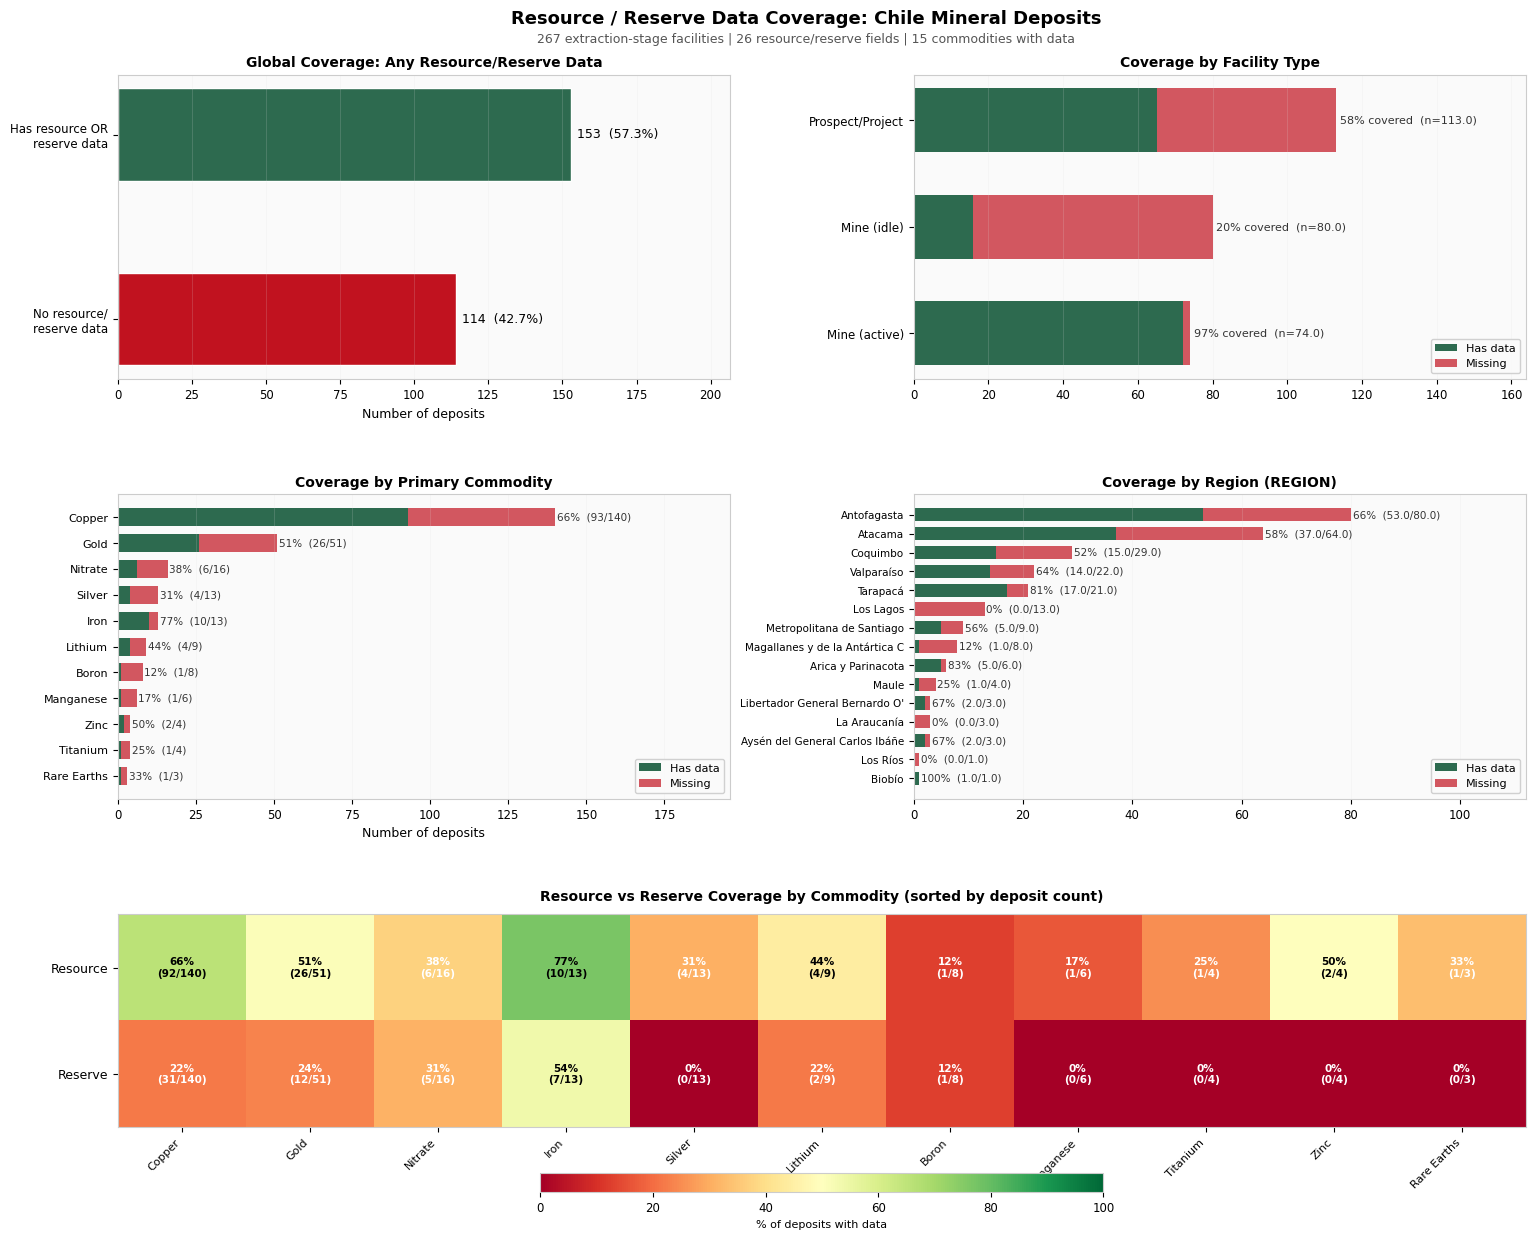

In [84]:
"""
Missing Resource/Reserve Data Analysis
Run after Part A of the Chile pipeline (requires `combined` DataFrame in memory).
Produces a single figure with 5 panels analyzing data gaps.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import os

# ── If running standalone, load from saved inventory ──
# If `combined` is already in memory from the notebook, skip this block.
BASE_DIR = "/Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile"
PRELIM = os.path.join(BASE_DIR, "Preliminary")
OUT_DIR = os.path.join(BASE_DIR, "Outputs")

inv = pd.read_csv(os.path.join(PRELIM, "Chile_Minerals_Inventory.csv"))

# ── Identify resource/reserve columns ──
res_cols = sorted([c for c in inv.columns if c.endswith(("_Resource", "_Reserve"))])
commodities_with_data = sorted(set(c.rsplit("_", 1)[0] for c in res_cols))

# ── Build per-facility missing matrix ──
# Only look at extraction-stage facilities (mines/prospects)
EXTRACTION_TYPES = ["Mine (active)", "Mine (idle)", "Prospect/Project", "Mine (USGS)"]
mines = inv[inv["FACILITY_TYPE"].isin(EXTRACTION_TYPES)].copy()

# For each mine, check: does it have ANY resource or reserve value?
mines["has_any_resource"] = mines[res_cols].notna().any(axis=1)

# Parse commodity list to check commodity-specific missingness
def parse_comms(val):
    if pd.isna(val):
        return []
    return [x.strip() for x in str(val).replace(",", "-").replace("/", "-").split("-") if x.strip()]

if "ALL_COMMODITIES_RAW" in mines.columns:
    mines["_comm_list"] = mines["ALL_COMMODITIES_RAW"].apply(parse_comms)
elif "COMMODITY_LIST" in mines.columns:
    mines["_comm_list"] = mines["COMMODITY_LIST"].apply(
        lambda x: [c.strip() for c in str(x).split(",")] if pd.notna(x) else [])
else:
    mines["_comm_list"] = mines["PRIMARY_COMMODITY"].apply(lambda x: [x] if pd.notna(x) else [])

# For each mine, check if it has resource data for its PRIMARY commodity
def has_primary_resource(row):
    pc = row.get("PRIMARY_COMMODITY", "")
    if pd.isna(pc) or pc == "":
        return False
    res_col = f"{pc}_Resource"
    rev_col = f"{pc}_Reserve"
    has_res = res_col in inv.columns and pd.notna(row.get(res_col))
    has_rev = rev_col in inv.columns and pd.notna(row.get(rev_col))
    return has_res or has_rev

mines["has_primary_resource"] = mines.apply(has_primary_resource, axis=1)

# ── Plotting ──
plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 8.5,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#cccccc", "grid.color": "#e0e0e0", "grid.linewidth": 0.4,
})

fig = plt.figure(figsize=(16, 13))
fig.suptitle("Resource / Reserve Data Coverage: Chile Mineral Deposits",
             fontsize=13, fontweight="bold", y=0.98)
fig.text(0.5, 0.955,
         f"{len(mines)} extraction-stage facilities | {len(res_cols)} resource/reserve fields | "
         f"{len(commodities_with_data)} commodities with data",
         ha="center", fontsize=9, color="#555555")

gs = gridspec.GridSpec(3, 2, hspace=0.38, wspace=0.30,
                       left=0.07, right=0.95, top=0.93, bottom=0.05)

# Colours
COL_HAS = "#2d6a4f"
COL_MISS = "#c1121f"
COL_PARTIAL = "#e9c46a"

# ═══════════════════════════════════════════════════════════
# Panel 0: Global summary (top-left)
# ═══════════════════════════════════════════════════════════
ax0 = fig.add_subplot(gs[0, 0])

global_stats = {
    "Has resource OR\nreserve data": mines["has_any_resource"].sum(),
    "No resource/\nreserve data": (~mines["has_any_resource"]).sum(),
}
bars = ax0.barh(list(global_stats.keys()), list(global_stats.values()),
                color=[COL_HAS, COL_MISS], edgecolor="white", height=0.5)
for bar, val in zip(bars, global_stats.values()):
    pct = val / len(mines) * 100
    ax0.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f"{val}  ({pct:.1f}%)", va="center", fontsize=9)
ax0.set_xlim(0, max(global_stats.values()) * 1.35)
ax0.set_title("Global Coverage: Any Resource/Reserve Data", fontweight="bold")
ax0.set_xlabel("Number of deposits")
ax0.invert_yaxis()
ax0.grid(axis="x", alpha=0.3)

# ═══════════════════════════════════════════════════════════
# Panel 1: Coverage by facility type (top-right)
# ═══════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 1])

type_stats = mines.groupby("FACILITY_TYPE").agg(
    total=("has_any_resource", "size"),
    has_data=("has_any_resource", "sum")
).sort_values("total", ascending=True)
type_stats["missing"] = type_stats["total"] - type_stats["has_data"]
type_stats["pct_has"] = (type_stats["has_data"] / type_stats["total"] * 100).round(1)

y_pos = range(len(type_stats))
ax1.barh(y_pos, type_stats["has_data"], color=COL_HAS, label="Has data", height=0.6)
ax1.barh(y_pos, type_stats["missing"], left=type_stats["has_data"],
         color=COL_MISS, label="Missing", height=0.6, alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(type_stats.index)
for i, (_, row) in enumerate(type_stats.iterrows()):
    ax1.text(row["total"] + 1, i, f'{row["pct_has"]:.0f}% covered  (n={row["total"]})',
             va="center", fontsize=8, color="#333")
ax1.set_xlim(0, type_stats["total"].max() * 1.45)
ax1.set_title("Coverage by Facility Type", fontweight="bold")
ax1.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax1.grid(axis="x", alpha=0.3)

# ═══════════════════════════════════════════════════════════
# Panel 2: Coverage by commodity (middle-left)
# ═══════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1, 0])

# For each commodity, count how many mines list it and how many have resource data for it
comm_coverage = []
all_comms = mines["PRIMARY_COMMODITY"].dropna().unique()
for comm in sorted(all_comms):
    subset = mines[mines["PRIMARY_COMMODITY"] == comm]
    total = len(subset)
    res_col = f"{comm}_Resource"
    rev_col = f"{comm}_Reserve"
    n_res = subset[res_col].notna().sum() if res_col in subset.columns else 0
    n_rev = subset[rev_col].notna().sum() if rev_col in subset.columns else 0
    n_either = subset.apply(
        lambda r: pd.notna(r.get(res_col)) or pd.notna(r.get(rev_col)), axis=1).sum() \
        if (res_col in subset.columns or rev_col in subset.columns) else 0
    comm_coverage.append({
        "commodity": comm, "total": total,
        "has_resource": int(n_res), "has_reserve": int(n_rev),
        "has_either": int(n_either),
        "missing": total - int(n_either),
        "pct": round(n_either / total * 100, 1) if total > 0 else 0,
    })

cc = pd.DataFrame(comm_coverage).sort_values("total", ascending=True)
cc = cc[cc["total"] >= 1]  # keep all

y_pos = range(len(cc))
ax2.barh(y_pos, cc["has_either"], color=COL_HAS, label="Has data", height=0.7)
ax2.barh(y_pos, cc["missing"], left=cc["has_either"],
         color=COL_MISS, label="Missing", height=0.7, alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(cc["commodity"], fontsize=8)
for i, (_, row) in enumerate(cc.iterrows()):
    label = f'{row["pct"]:.0f}%  ({row["has_either"]}/{row["total"]})'
    ax2.text(row["total"] + 0.5, i, label, va="center", fontsize=7.5, color="#333")
ax2.set_xlim(0, cc["total"].max() * 1.4)
ax2.set_title("Coverage by Primary Commodity", fontweight="bold")
ax2.set_xlabel("Number of deposits")
ax2.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax2.grid(axis="x", alpha=0.3)

# ═══════════════════════════════════════════════════════════
# Panel 3: Coverage by region (middle-right)
# ═══════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 1])

# Use REGION column; fall back to NOMBRE_REGION or ADM1
reg_col = None
for candidate in ["REGION", "NOMBRE_REGION", "ADM1"]:
    if candidate in mines.columns and mines[candidate].notna().sum() > 10:
        reg_col = candidate
        break

if reg_col:
    reg_stats = mines.groupby(reg_col).agg(
        total=("has_any_resource", "size"),
        has_data=("has_any_resource", "sum")
    ).sort_values("total", ascending=True)
    reg_stats["missing"] = reg_stats["total"] - reg_stats["has_data"]
    reg_stats["pct"] = (reg_stats["has_data"] / reg_stats["total"] * 100).round(1)

    # Truncate long region names
    labels = [str(r)[:30] for r in reg_stats.index]
    y_pos = range(len(reg_stats))
    ax3.barh(y_pos, reg_stats["has_data"], color=COL_HAS, label="Has data", height=0.7)
    ax3.barh(y_pos, reg_stats["missing"], left=reg_stats["has_data"],
             color=COL_MISS, label="Missing", height=0.7, alpha=0.7)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(labels, fontsize=7.5)
    for i, (_, row) in enumerate(reg_stats.iterrows()):
        ax3.text(row["total"] + 0.3, i,
                 f'{row["pct"]:.0f}%  ({row["has_data"]}/{row["total"]})',
                 va="center", fontsize=7.5, color="#333")
    ax3.set_xlim(0, reg_stats["total"].max() * 1.4)
    ax3.set_title(f"Coverage by Region ({reg_col})", fontweight="bold")
    ax3.legend(loc="lower right", fontsize=8, framealpha=0.9)
else:
    ax3.text(0.5, 0.5, "No region column found", ha="center", va="center", transform=ax3.transAxes)
    ax3.set_title("Coverage by Region", fontweight="bold")
ax3.grid(axis="x", alpha=0.3)

# ═══════════════════════════════════════════════════════════
# Panel 4: Heatmap - commodity x resource/reserve fill (bottom, full width)
# ═══════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[2, :])

# Build matrix: rows = commodities (sorted by total deposits), cols = Resource / Reserve
heat_data = []
for comm in sorted(all_comms):
    subset = mines[mines["PRIMARY_COMMODITY"] == comm]
    total = len(subset)
    if total == 0:
        continue
    res_col = f"{comm}_Resource"
    rev_col = f"{comm}_Reserve"
    n_res = subset[res_col].notna().sum() if res_col in subset.columns else 0
    n_rev = subset[rev_col].notna().sum() if rev_col in subset.columns else 0
    heat_data.append({
        "commodity": comm, "total": total,
        "Resource (%)": round(n_res / total * 100, 1),
        "Reserve (%)": round(n_rev / total * 100, 1),
        "Resource (n)": int(n_res),
        "Reserve (n)": int(n_rev),
    })

hdf = pd.DataFrame(heat_data).sort_values("total", ascending=False)
matrix = hdf[["Resource (%)", "Reserve (%)"]].values
comm_labels = hdf["commodity"].values

im = ax4.imshow(matrix.T, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax4.set_xticks(range(len(comm_labels)))
ax4.set_xticklabels(comm_labels, rotation=45, ha="right", fontsize=8)
ax4.set_yticks([0, 1])
ax4.set_yticklabels(["Resource", "Reserve"], fontsize=9)

# Annotate cells
for i in range(len(comm_labels)):
    for j, col_type in enumerate(["Resource", "Reserve"]):
        pct = matrix[i, j]
        n = hdf.iloc[i][f"{col_type} (n)"]
        total = hdf.iloc[i]["total"]
        color = "white" if pct < 40 else "black"
        ax4.text(i, j, f"{pct:.0f}%\n({n}/{total})",
                 ha="center", va="center", fontsize=7.5, color=color, fontweight="bold")

cbar = fig.colorbar(im, ax=ax4, orientation="horizontal", pad=0.15, shrink=0.4, aspect=30)
cbar.set_label("% of deposits with data", fontsize=8)
ax4.set_title("Resource vs Reserve Coverage by Commodity (sorted by deposit count)",
              fontweight="bold", pad=10)

# ── Save ──
out_path = os.path.join(OUT_DIR, "Missing_Data_Analysis.png")
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()